# Importing Libraries

In [12]:
from transformers import pipeline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Creating, Initial Testing of Pipeline

Going to create a cimple pipeline using this model. It will probably have to be more involved than just a couple python calls in the future, but for testing right now it's pretty convenient. Like they recommend, I'll probably end up training this on my own handwriting.

In [13]:
transfer = pipeline("image-to-text", model="microsoft/trocr-base-handwritten")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


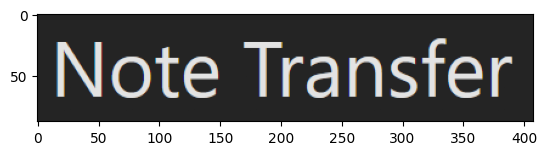

In [18]:
%matplotlib inline

image_path = r'images\test-transfer.png'
image = mpimg.imread(image_path)
image_plot = plt.imshow(image)

In [19]:
result = transfer(image_path)
text = result[0]['generated_text']
print(text)

Note Transfer


Looking pretty good! It is able to recognize text, but let's test some neat handwriting.

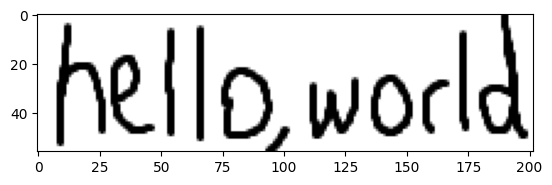

In [20]:
image_path = r'images\handwriting-test.png'
image = mpimg.imread(image_path)
image_plot = plt.imshow(image)

In [21]:
result = transfer(image_path)
text = result[0]['generated_text']
print(text)

hello , world


How about actual scanned handwriting?

In [22]:
def test_image(image_path):
    # Get image, show it
    image = mpimg.imread(image_path)
    image_plot = plt.imshow(image)
    plt.show()

    # Run trhough model, show output
    result = transfer(image_path)
    text = result[0]['generated_text']
    print(text)

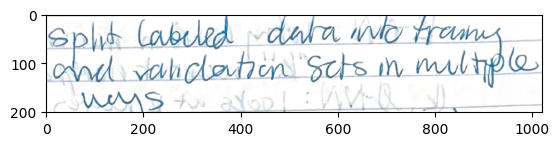

other grandchildren in multiple


In [23]:
test_image(r'images\real-handwriting-large.png')

Not really looking too great there. Not sure where it's reading. I like it had trouble with multiple lines, but I'll have to read more into the model documentation for that. Let's try out a small snippet:

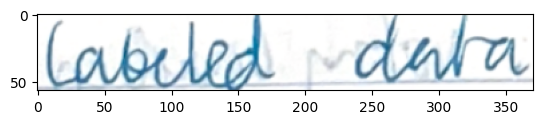

labuted pollution


In [25]:
test_image(r'images\real-handwriting-small.png')

Wow yeah that's not great. Let's see if it's the extra stuff that comes with real handwriting. I'll trace over it in paint, so it's just black and white.

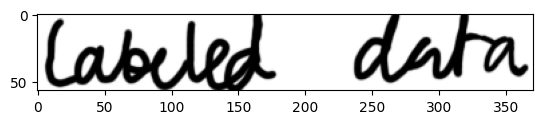

labeled data


In [26]:

test_image(r'images\real-handwriting-small-clean.png')

Okay that's good to see. SEe I'll definitely need to look into standardizing these images for contract, color, etc.